<div style="background:radial-gradient(120% 150% at 100% 0%,rgba(10,132,255,.20) 0%,rgba(0,0,0,0) 55%),#000000;border:1px solid #2C2C2E;border-radius:22px;padding:48px 48px 42px;font-family:-apple-system,BlinkMacSystemFont,'SF Pro Display','SF Pro Text','Helvetica Neue',Helvetica,Arial,sans-serif;">
  <div style="font-size:13px;font-weight:500;color:#8E8E93;letter-spacing:.02em;">Machine Learning &nbsp;|&nbsp; Retention Analytics</div>
  <div style="font-size:46px;font-weight:600;letter-spacing:-.035em;color:#F5F5F7;margin:12px 0 14px;line-height:1.08;">Customer churn prediction</div>
  <div style="font-size:19px;color:#A1A1A6;max-width:640px;line-height:1.45;">An interpretable classifier that flags at-risk customers.</div>
  <div style="margin-top:30px;font-size:13px;color:#636366;">python &nbsp; -&nbsp; pandas &nbsp; -&nbsp; scikit-learn &nbsp; -&nbsp; matplotlib</div>
</div>


## Overview

| Area | Approach |
|---|---|
| **Data splitting** | Stratified train/test split preserves the class balance |
| **Class imbalance** | `class_weight='balanced'` upweights the minority (churn) class |
| **Preprocessing** | Scaling fitted on training data only, so there is no leakage |
| **Model selection** | Multi-model benchmark on Accuracy, Precision, Recall, F1 and ROC-AUC |
| **Validation** | 5-fold stratified cross-validation for stable metric estimates |
| **Interpretability** | Confusion matrix, ROC curve and feature-importance analysis |
| **Deployment** | Serialised model artefact plus a single-customer inference helper |

## 1. Setup
Imports, reproducibility and a shared visual theme so every chart and table looks consistent.

In [1]:
# Import libraries
import logging
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from IPython.display import Markdown, display
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve,
)
import joblib

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Output folders
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

In [2]:
# Visual theme
COLOR_DEFAULT   = '#B8C4CF' 
COLOR_TOP       = '#264653'
COLOR_BOTTOM    = '#D95F59'
COLOR_TEXT      = '#333333'
COLOR_SECONDARY = '#777777'
COLOR_GRID      = '#E8E8E8'

CMAP_TOP = LinearSegmentedColormap.from_list('top', [COLOR_GRID, COLOR_TOP])

plt.rcParams.update({
    'figure.dpi'          : 110,
    'savefig.dpi'         : 200,
    'savefig.bbox'        : 'tight',
    'figure.facecolor'    : 'white',
    'axes.facecolor'      : 'white',
    'savefig.facecolor'   : 'white',
    'font.family'         : 'sans-serif',
    'font.sans-serif'     : ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size'           : 10.5,
    'text.color'          : COLOR_TEXT,
    'axes.titlesize'      : 12.5,
    'axes.titleweight'    : 'bold',
    'axes.titlelocation'  : 'left',
    'axes.titlepad'       : 12,
    'axes.titlecolor'     : COLOR_TEXT,
    'axes.labelcolor'     : COLOR_TEXT,
    'axes.labelsize'      : 10.5,
    'axes.edgecolor'      : COLOR_SECONDARY,
    'axes.linewidth'      : 0.8,
    'axes.spines.top'     : False,
    'axes.spines.right'   : False,
    'axes.grid'           : True,
    'axes.grid.axis'      : 'y',
    'axes.axisbelow'      : True,
    'grid.color'          : COLOR_GRID,
    'grid.linewidth'      : 0.8,
    'xtick.color'         : COLOR_SECONDARY,
    'ytick.color'         : COLOR_SECONDARY,
    'xtick.labelcolor'    : COLOR_TEXT,
    'ytick.labelcolor'    : COLOR_TEXT,
    'legend.frameon'      : False,
    'legend.fontsize'     : 10,
    'legend.labelcolor'   : COLOR_TEXT,
})


# Helpers
def save_fig(name):
    """Save the current figure to ./figures/<name>.png"""
    plt.savefig(FIG_DIR / f'{name}.png')


def show(df, title=None, formatter=None, precision=2, bold_max=None, axis=0):
    """Display a DataFrame under a plain bold title.

    formatter : optional {column: format-string} overrides
    bold_max  : True (all columns) or a list of columns whose maximum is set in bold
    axis      : 0 = best per column, 1 = best per row
    """
    if title:
        display(Markdown(f'**{title}**'))
    sty = df.style.format(precision=precision, na_rep='n/a')
    if formatter:
        sty = sty.format(formatter, na_rep='n/a')
    if bold_max:
        sty = sty.highlight_max(subset=None if bold_max is True else bold_max,
                                axis=axis, props='font-weight: bold;')
    display(sty)


def note(text):
    """Plain block-quote note (supports **bold** and `code`)."""
    display(Markdown('> ' + text))


print('Environment ready.')

Environment ready.


## 2. Load & Validate Data
Read the raw file and run basic quality checks before any modelling.

In [3]:
DATA_PATH = 'customer_churn.csv'

df = pd.read_csv(DATA_PATH)

# Drop spurious CSV index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f'Rows: {len(df):,}   Columns: {df.shape[1]}   Target: Churn (1 = churned, 0 = retained)')
df.head()

Rows: 3,333   Columns: 11   Target: Churn (1 = churned, 0 = retained)


,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,Yes,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,Yes,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,Yes,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,No,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,No,0,0.0,3,166.7,113,41.0,7.42,10.1


In [4]:
# Data quality checks
n_missing = int(df.isnull().sum().sum())
n_dupes   = int(df.duplicated().sum())

print(f'Missing values : {n_missing}')
print(f'Duplicate rows : {n_dupes}')

schema = pd.DataFrame({
    'Type'     : df.dtypes.astype(str),
    'Missing'  : df.isnull().sum(),
    'Missing %': df.isnull().mean() * 100,
    'Unique'   : df.nunique(),
})
show(schema, 'Schema and completeness', formatter={'Missing %': '{:.1f}%'})

show(df.describe().T, 'Summary statistics')

Missing values : 0
Duplicate rows : 0


**Schema and completeness**

,Type,Missing,Missing %,Unique
Churn,int64,0,0.0%,2
AccountWeeks,int64,0,0.0%,212
ContractRenewal,str,0,0.0%,2
DataPlan,int64,0,0.0%,2
DataUsage,float64,0,0.0%,174
CustServCalls,int64,0,0.0%,10
DayMins,float64,0,0.0%,1667
DayCalls,int64,0,0.0%,119
MonthlyCharge,float64,0,0.0%,627
OverageFee,float64,0,0.0%,1024


**Summary statistics**

,count,mean,std,min,25%,50%,75%,max
Churn,3333.00,0.14,0.35,0.00,0.00,0.00,0.00,1.00
AccountWeeks,3333.00,101.06,39.82,1.00,74.00,101.00,127.00,243.00
DataPlan,3333.00,0.28,0.45,0.00,0.00,0.00,1.00,1.00
DataUsage,3333.00,0.82,1.27,0.00,0.00,0.00,1.78,5.40
CustServCalls,3333.00,1.56,1.32,0.00,1.00,1.00,2.00,9.00
DayMins,3333.00,179.78,54.47,0.00,143.70,179.40,216.40,350.80
DayCalls,3333.00,100.44,20.07,0.00,87.00,101.00,114.00,165.00
MonthlyCharge,3333.00,56.31,16.43,14.00,45.00,53.50,66.20,111.30
OverageFee,3333.00,10.05,2.54,0.00,8.33,10.07,11.77,18.19
RoamMins,3333.00,10.24,2.79,0.00,8.50,10.30,12.10,20.00


Retained (0): 2,850  (85.5%)
Churned  (1): 483  (14.5%)


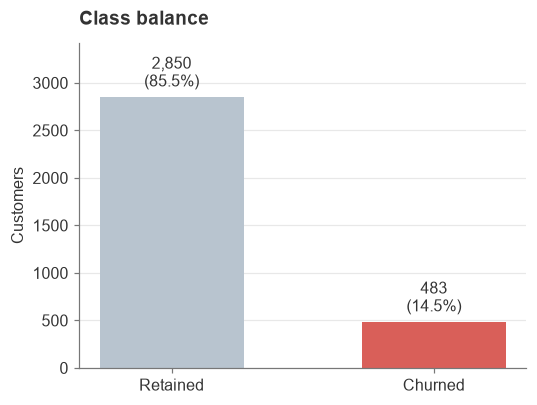

> **Class imbalance** (~86 / 14 split). Accuracy alone is a misleading metric here, so **Recall** and **ROC-AUC** are the primary evaluation metrics.

In [5]:
# Class distribution
churn_counts = df['Churn'].value_counts().sort_index()
churn_rate   = df['Churn'].mean() * 100

print(f'Retained (0): {churn_counts[0]:,}  ({100 - churn_rate:.1f}%)')
print(f'Churned  (1): {churn_counts[1]:,}  ({churn_rate:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 3.8))
bars = ax.bar(['Retained', 'Churned'], churn_counts.values,
              color=[COLOR_DEFAULT, COLOR_BOTTOM], width=0.55)
ax.bar_label(bars, labels=[f'{v:,}\n({v / churn_counts.sum():.1%})' for v in churn_counts.values],
             padding=4, color=COLOR_TEXT)
ax.set_ylim(0, churn_counts.max() * 1.2)
ax.grid(False, axis='x')
ax.set_title('Class balance')
ax.set_ylabel('Customers')
plt.tight_layout()
save_fig('00_class_balance')
plt.show()

note(f'**Class imbalance** (~{100 - churn_rate:.0f} / {churn_rate:.0f} split). '
     'Accuracy alone is a misleading metric here, so **Recall** and **ROC-AUC** are the primary evaluation metrics.')

## 3. EDA
What separates customers who leave from those who stay?

In [6]:
churned     = df[df['Churn'] == 1]
non_churned = df[df['Churn'] == 0]

numeric_cols = df.select_dtypes(include='number').columns.drop('Churn')
comparison = pd.DataFrame({
    'Retained': non_churned[numeric_cols].mean(),
    'Churned' : churned[numeric_cols].mean(),
})
comparison['Difference %'] = ((comparison['Churned'] - comparison['Retained'])
                              / comparison['Retained'] * 100).replace([np.inf, -np.inf], np.nan)

show(comparison, 'Average feature values: churned vs. retained customers',
     formatter={'Difference %': '{:+.1f}%'})

**Average feature values: churned vs. retained customers**

,Retained,Churned,Difference %
AccountWeeks,100.793684,102.664596,+1.9%
DataPlan,0.295439,0.165631,-43.9%
DataUsage,0.862151,0.546957,-36.6%
CustServCalls,1.449825,2.229814,+53.8%
DayMins,175.175754,206.914079,+18.1%
DayCalls,100.283158,101.335404,+1.0%
MonthlyCharge,55.816246,59.190062,+6.0%
OverageFee,9.954618,10.623085,+6.7%
RoamMins,10.158877,10.700000,+5.3%


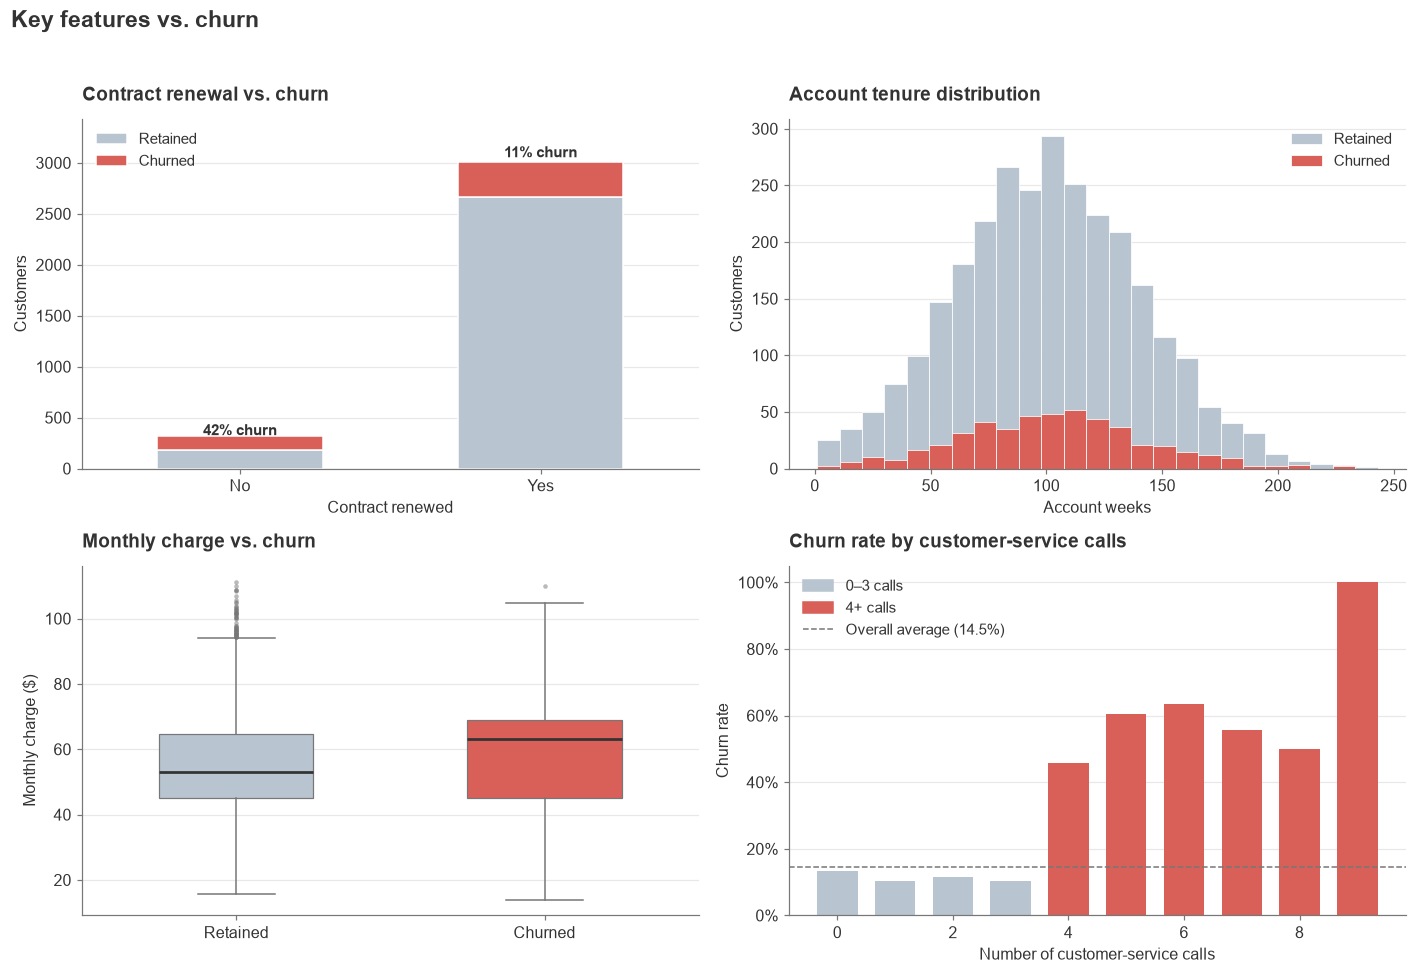

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Key features vs. churn', fontsize=15, fontweight='bold',
             x=0.01, ha='left', color=COLOR_TEXT)

# 1 Contract renewal vs churn (counts, annotated with churn rate)
ax = axes[0, 0]
ct = df.groupby('ContractRenewal')['Churn'].value_counts().unstack().fillna(0)
ct.columns = ['Retained', 'Churned']
ct.plot(kind='bar', stacked=True, ax=ax, color=[COLOR_DEFAULT, COLOR_BOTTOM], width=0.55, edgecolor='white')
totals = ct.sum(axis=1)
for i, (tot, rate) in enumerate(zip(totals, ct['Churned'] / totals)):
    ax.text(i, tot * 1.015, f'{rate:.0%} churn', ha='center', fontsize=10,
            fontweight='bold', color=COLOR_TEXT)
ax.set_ylim(0, totals.max() * 1.14)
ax.set_title('Contract renewal vs. churn')
ax.set_xlabel('Contract renewed')
ax.set_ylabel('Customers')
ax.tick_params(axis='x', rotation=0)
ax.grid(False, axis='x')
ax.legend(title=None)

# 2 Tenure distribution
ax = axes[0, 1]
bins = np.histogram_bin_edges(df['AccountWeeks'], bins=25)
ax.hist(non_churned['AccountWeeks'], bins=bins, color=COLOR_DEFAULT,
        edgecolor='white', linewidth=0.5, label='Retained')
ax.hist(churned['AccountWeeks'], bins=bins, color=COLOR_BOTTOM,
        edgecolor='white', linewidth=0.5, label='Churned')
ax.set_title('Account tenure distribution')
ax.set_xlabel('Account weeks')
ax.set_ylabel('Customers')
ax.legend()

# 3 Monthly charge box plot
ax = axes[1, 0]
bp = ax.boxplot(
    [non_churned['MonthlyCharge'], churned['MonthlyCharge']],
    patch_artist=True, widths=0.5,
    medianprops=dict(color=COLOR_TEXT, linewidth=1.8),
    whiskerprops=dict(color=COLOR_SECONDARY), capprops=dict(color=COLOR_SECONDARY),
    flierprops=dict(marker='o', markersize=3, markerfacecolor=COLOR_SECONDARY,
                    markeredgecolor='none', alpha=0.5),
)
for patch, col in zip(bp['boxes'], [COLOR_DEFAULT, COLOR_BOTTOM]):
    patch.set(facecolor=col, edgecolor=COLOR_SECONDARY, linewidth=0.8)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Retained', 'Churned'])
ax.set_title('Monthly charge vs. churn')
ax.set_ylabel('Monthly charge ($)')

# 4 Customer-service calls
ax = axes[1, 1]
csc_churn = df.groupby('CustServCalls')['Churn'].mean() * 100
bar_cols  = [COLOR_BOTTOM if x >= 4 else COLOR_DEFAULT for x in csc_churn.index]
ax.bar(csc_churn.index, csc_churn.values, color=bar_cols, width=0.7)
ax.axhline(churn_rate, color=COLOR_SECONDARY, linestyle='--', linewidth=1)
ax.set_title('Churn rate by customer-service calls')
ax.set_xlabel('Number of customer-service calls')
ax.set_ylabel('Churn rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.legend(handles=[Patch(color=COLOR_DEFAULT, label='0–3 calls'),
                   Patch(color=COLOR_BOTTOM,  label='4+ calls'),
                   Line2D([0], [0], color=COLOR_SECONDARY, linestyle='--', linewidth=1,
                          label=f'Overall average ({churn_rate:.1f}%)')], loc='upper left')

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_fig('01_eda_overview')
plt.show()

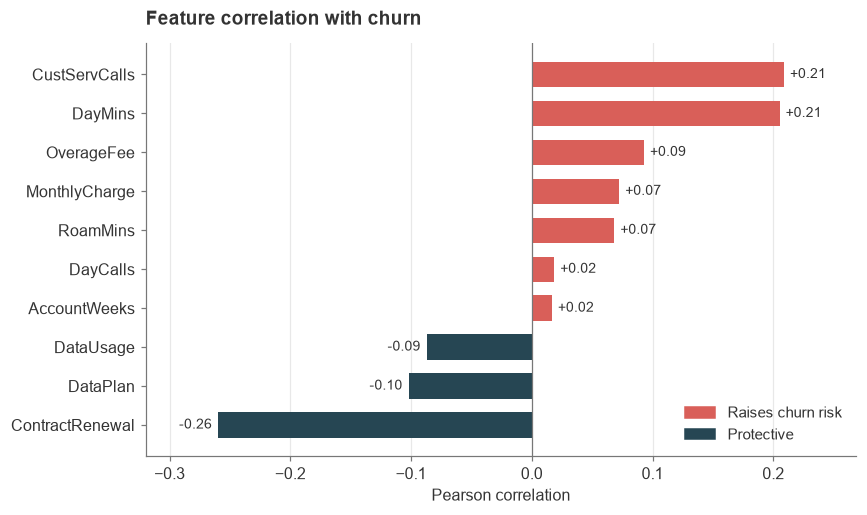

In [8]:
# Feature correlation with target
df_enc = df.copy()
df_enc['ContractRenewal'] = (df_enc['ContractRenewal'] == 'Yes').astype(int)
correlations = df_enc.corr()['Churn'].drop('Churn').sort_values()

fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.barh(correlations.index, correlations.values, height=0.65,
               color=[COLOR_BOTTOM if v > 0 else COLOR_TOP for v in correlations])
ax.bar_label(bars, labels=[f'{v:+.2f}' for v in correlations], padding=4, fontsize=9, color=COLOR_TEXT)
ax.axvline(0, color=COLOR_SECONDARY, linewidth=0.8)
ax.grid(False, axis='y')
ax.grid(True,  axis='x')
pad = 0.06
ax.set_xlim(min(correlations.min() - pad, -pad), max(correlations.max() + pad, pad))
ax.set_title('Feature correlation with churn')
ax.set_xlabel('Pearson correlation')
ax.legend(handles=[Patch(color=COLOR_BOTTOM, label='Raises churn risk'),
                   Patch(color=COLOR_TOP,    label='Protective')], loc='lower right')
plt.tight_layout()
save_fig('02_correlation')
plt.show()

## 4. Preprocessing
Encode categoricals, split the data with stratification and scale without leaking test information.

In [9]:
# Feature engineering
target   = df['Churn']
features = pd.get_dummies(df.drop(columns=['Churn']), columns=['ContractRenewal'], dtype=int)

print(f'Samples  : {features.shape[0]:,}')
print(f'Features : {features.shape[1]} (after one-hot encoding)')
print('Columns  : ' + ', '.join(features.columns))

Samples  : 3,333
Features : 11 (after one-hot encoding)
Columns  : AccountWeeks, DataPlan, DataUsage, CustServCalls, DayMins, DayCalls, MonthlyCharge, OverageFee, RoamMins, ContractRenewal_No, ContractRenewal_Yes


In [10]:
# Stratified train/test split. Stratify=target preserves the class ratio in both sets (key for imbalanced data)
TEST_SIZE = 0.30

x_train, x_test, y_train, y_test = train_test_split(
    features, target,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=target,
)

split_summary = pd.DataFrame({
    'Rows'      : [len(x_train), len(x_test)],
    'Churners'  : [int(y_train.sum()), int(y_test.sum())],
    'Churn rate': [y_train.mean() * 100, y_test.mean() * 100],
}, index=[f'Train ({1 - TEST_SIZE:.0%})', f'Test ({TEST_SIZE:.0%})'])

show(split_summary, 'Stratified split', formatter={'Rows': '{:,}', 'Churn rate': '{:.1f}%'})

**Stratified split**

,Rows,Churners,Churn rate
Train (70%),"2,333",338,14.5%
Test (30%),"1,000",145,14.5%


In [11]:
# Feature scaling (needed for Logistic Regression). Fit ONLY on training data to prevent data leakage

scaler     = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc  = scaler.transform(x_test)          # transform, not fit_transform

print('Scaler fitted on training data only: no test-set information leaks into preprocessing.')

Scaler fitted on training data only: no test-set information leaks into preprocessing.


## 5. Model benchmarking
Three candidates, one held-out test set, several metrics.

In [12]:
# Define candidate models
candidates = {
    'Logistic Regression (baseline)': {
        'model'  : LogisticRegression(max_iter=1000, random_state=SEED),
        'scaled' : True,
        'note'   : 'Original notebook approach, no imbalance handling',
    },
    'Logistic Regression (balanced)': {
        'model'  : LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
        'scaled' : True,
        'note'   : 'class_weight="balanced" upweights the minority class',
    },
    'Random Forest (balanced)': {
        'model'  : RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                          random_state=SEED, n_jobs=-1),
        'scaled' : False,   # tree models are scale-invariant
        'note'   : 'Ensemble; handles non-linearity and feature interactions',
    },
}

# Train and evaluate each candidate
results = {}
for name, cfg in candidates.items():
    mdl = cfg['model']
    Xtr = x_train_sc if cfg['scaled'] else x_train
    Xte = x_test_sc  if cfg['scaled'] else x_test

    mdl.fit(Xtr, y_train)
    y_pred = mdl.predict(Xte)
    y_prob = mdl.predict_proba(Xte)[:, 1]

    results[name] = {
        'Accuracy' : round(accuracy_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred), 3),
        'Recall'   : round(recall_score(y_test, y_pred), 3),
        'F1'       : round(f1_score(y_test, y_pred), 3),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 3),
        'Note'     : cfg['note'],
    }

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
results_df  = pd.DataFrame(results).T
results_df[metric_cols] = results_df[metric_cols].astype(float)

show(results_df, 'Model comparison: held-out test set', precision=3, bold_max=metric_cols)

**Model comparison: held-out test set**

,Accuracy,Precision,Recall,F1,ROC-AUC,Note
Logistic Regression (baseline),0.870,0.632,0.248,0.356,0.828,"Original notebook approach, no imbalance handling"
Logistic Regression (balanced),0.765,0.356,0.766,0.486,0.829,"class_weight=""balanced"" upweights the minority class"
Random Forest (balanced),0.915,0.688,0.759,0.721,0.881,Ensemble; handles non-linearity and feature interactions


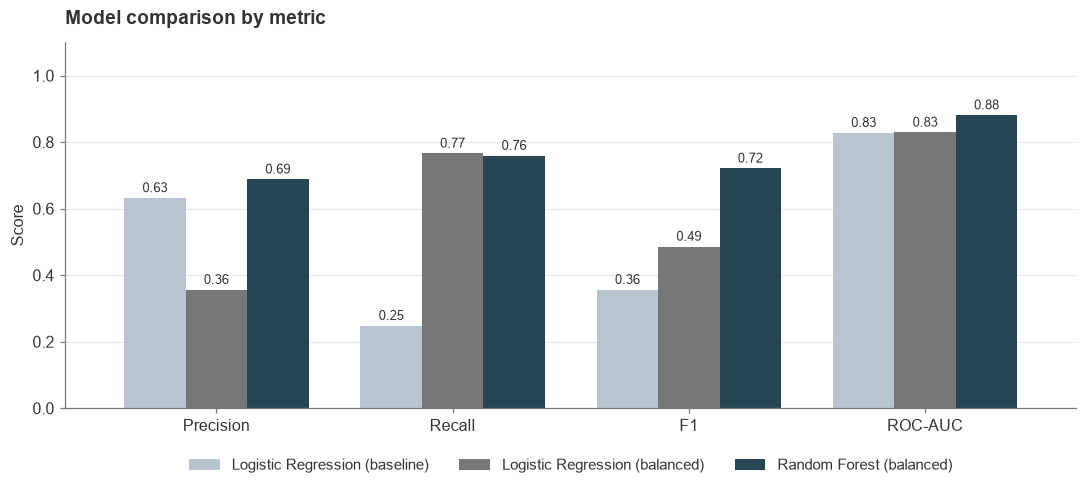

In [13]:
# Visual comparison
plot_metrics = ['Precision', 'Recall', 'F1', 'ROC-AUC']
palette      = [COLOR_DEFAULT, COLOR_SECONDARY, COLOR_TOP, COLOR_BOTTOM][:len(results_df)]

ax = results_df[plot_metrics].T.plot(kind='bar', figsize=(10, 4.6), width=0.78, color=palette)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8.5, padding=2, color=COLOR_TEXT)
ax.set_ylim(0, 1.1)
ax.grid(False, axis='x')
ax.set_title('Model comparison by metric')
ax.set_ylabel('Score')
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=len(results_df), title=None)
plt.tight_layout()
save_fig('03_model_comparison')
plt.show()

> **How to read the table**
> - **Accuracy** is inflated for every model because most customers never churn.
> - **Recall** shows how many actual churners we catch, which is the business-critical metric.
> - **Precision** shows how many flagged customers really churn, which determines the cost of wasted outreach.
> - **ROC-AUC** measures overall discriminative power regardless of threshold.
>
> Random Forest (balanced) achieves the best balance of Recall and Precision.

## 6. Best model: deep evaluation
Test-set performance, error breakdown and cross-validated stability for the selected model.

In [14]:
# Train the selected model
best_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
)
best_model.fit(x_train, y_train)

y_pred = best_model.predict(x_test)
y_prob = best_model.predict_proba(x_test)[:, 1]

accuracy  = round(accuracy_score(y_test, y_pred),  3)
precision = round(precision_score(y_test, y_pred), 3)
recall    = round(recall_score(y_test, y_pred),    3)
f1        = round(f1_score(y_test, y_pred),        3)
roc_auc   = round(roc_auc_score(y_test, y_prob),   3)

metrics = pd.DataFrame({'Score': {'Accuracy': accuracy, 'Precision': precision,
                                  'Recall': recall, 'F1': f1, 'ROC-AUC': roc_auc}})
show(metrics, 'Random Forest: test-set metrics', precision=3)

**Random Forest: test-set metrics**

,Score
Accuracy,0.915
Precision,0.688
Recall,0.759
F1,0.721
ROC-AUC,0.881


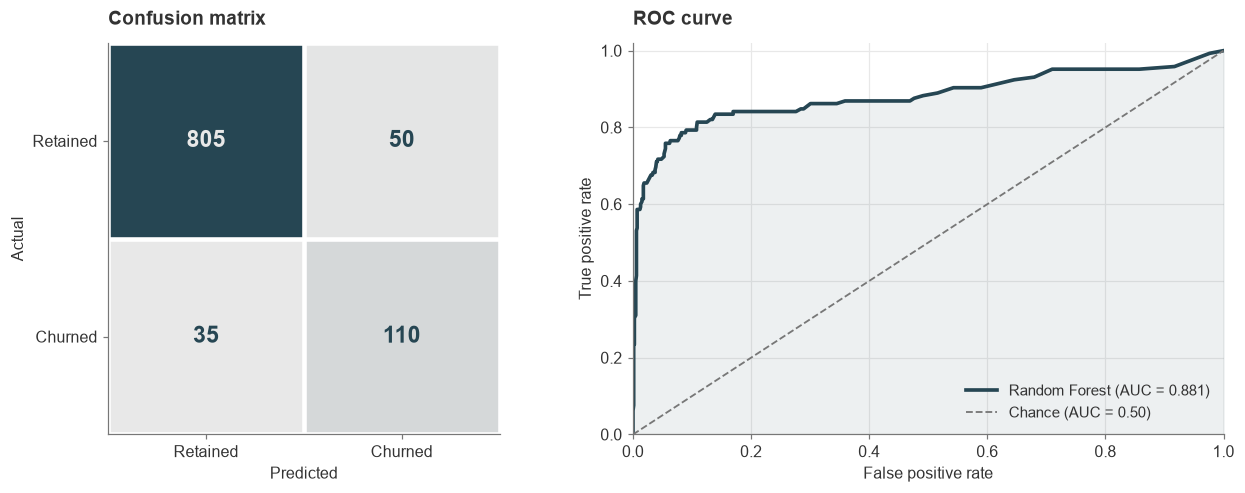

**Prediction outcomes**

,Meaning,Count
True negatives,Correctly predicted retained,805
False positives,Wrongly flagged as churn (wasted outreach),50
False negatives,Missed churners (lost revenue),35
True positives,Correctly caught churners,110


Churners caught: 110 of 145 (75.9% recall)


In [15]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned']).plot(
    ax=axes[0], colorbar=False, cmap=CMAP_TOP, values_format='d')
axes[0].grid(False)
axes[0].set_xticks(np.arange(-0.5, 2, 1), minor=True)
axes[0].set_yticks(np.arange(-0.5, 2, 1), minor=True)
axes[0].grid(True, which='minor', color='white', linewidth=3)
axes[0].tick_params(which='minor', length=0)
axes[0].set_title('Confusion matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
for t in axes[0].texts:
    t.set_fontsize(15)
    t.set_fontweight('bold')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color=COLOR_TOP, linewidth=2.4, label=f'Random Forest (AUC = {roc_auc:.3f})')
axes[1].fill_between(fpr, tpr, alpha=0.08, color=COLOR_TOP)
axes[1].plot([0, 1], [0, 1], linestyle='--', color=COLOR_SECONDARY, linewidth=1.2, label='Chance (AUC = 0.50)')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.02)
axes[1].set_title('ROC curve')
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].legend(loc='lower right')
axes[1].grid(True, axis='both')

plt.tight_layout()
save_fig('04_evaluation')
plt.show()

# Error breakdown
tn, fp, fn, tp = cm.ravel()
breakdown = pd.DataFrame({
    'Meaning': ['Correctly predicted retained', 'Wrongly flagged as churn (wasted outreach)',
                'Missed churners (lost revenue)', 'Correctly caught churners'],
    'Count'  : [tn, fp, fn, tp],
}, index=['True negatives', 'False positives', 'False negatives', 'True positives'])
show(breakdown, 'Prediction outcomes', formatter={'Count': '{:,}'})

print(f'Churners caught: {tp} of {tp + fn} ({tp / (tp + fn):.1%} recall)')

**5-fold cross-validation**

,Mean,Std,Min,Max
F1,0.743,0.033,0.699,0.785
Recall,0.741,0.040,0.670,0.781
ROC-AUC,0.900,0.025,0.856,0.921


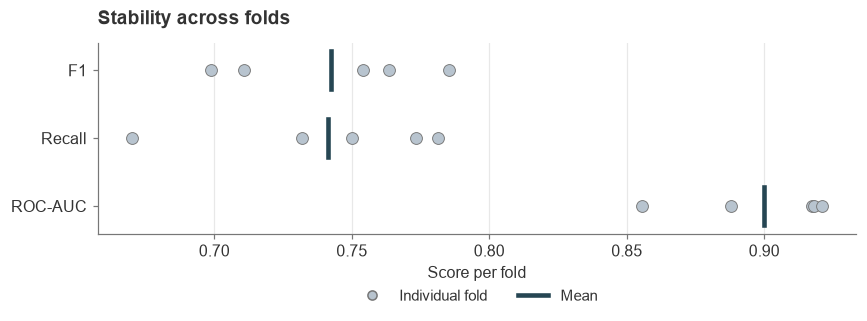

> The smaller the spread across folds, the more consistently the model generalises to unseen data.

In [16]:
# 5-Fold Stratified Cross-Validation. A single train/test split gives a point estimate that may be lucky or unlucky.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_model = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1
)

cv_out = cross_validate(cv_model, features, target, cv=cv, scoring=['f1', 'recall', 'roc_auc'])
cv_f1      = cv_out['test_f1']
cv_recall  = cv_out['test_recall']
cv_roc_auc = cv_out['test_roc_auc']

cv_scores = {'F1': cv_f1, 'Recall': cv_recall, 'ROC-AUC': cv_roc_auc}

cv_table = pd.DataFrame({
    'Mean': {m: s.mean() for m, s in cv_scores.items()},
    'Std' : {m: s.std()  for m, s in cv_scores.items()},
    'Min' : {m: s.min()  for m, s in cv_scores.items()},
    'Max' : {m: s.max()  for m, s in cv_scores.items()},
})
show(cv_table, '5-fold cross-validation', precision=3)

# Per-fold scores
fig, ax = plt.subplots(figsize=(8, 3.2))
for i, (m, s) in enumerate(cv_scores.items()):
    ax.scatter(s, np.full(len(s), i), s=60, color=COLOR_DEFAULT, edgecolor=COLOR_SECONDARY,
               linewidth=0.6, zorder=3)
    ax.plot([s.mean()] * 2, [i - 0.28, i + 0.28], color=COLOR_TOP, linewidth=3, zorder=4)
ax.set_yticks(range(len(cv_scores)))
ax.set_yticklabels(cv_scores.keys())
ax.invert_yaxis()
ax.grid(False, axis='y')
ax.grid(True,  axis='x')
ax.set_xlabel('Score per fold')
ax.set_title('Stability across folds')
ax.legend(handles=[Line2D([0], [0], marker='o', linestyle='', markerfacecolor=COLOR_DEFAULT,
                          markeredgecolor=COLOR_SECONDARY, label='Individual fold'),
                   Line2D([0], [0], color=COLOR_TOP, linewidth=3, label='Mean')],
          loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=2)
plt.tight_layout()
save_fig('05_cross_validation')
plt.show()

note('The smaller the spread across folds, the more consistently the model generalises to unseen data.')

## 7. Feature Importance
Which inputs does the model rely on most?

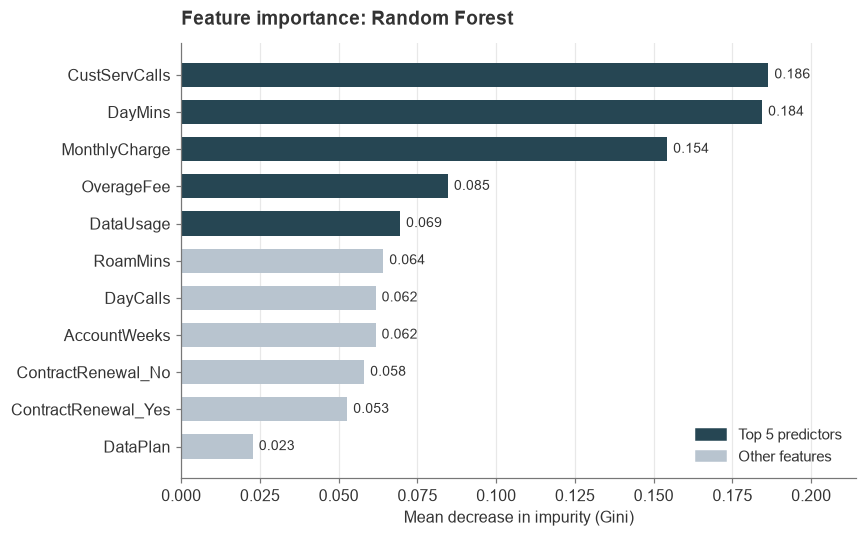

> **Strongest predictors of churn:** `CustServCalls` (0.186), `DayMins` (0.184), `MonthlyCharge` (0.154)

In [17]:
feat_imp = pd.Series(best_model.feature_importances_, index=features.columns).sort_values()
TOP_N    = 5

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(feat_imp.index, feat_imp.values, height=0.65,
               color=[COLOR_DEFAULT] * (len(feat_imp) - TOP_N) + [COLOR_TOP] * min(TOP_N, len(feat_imp)))
ax.bar_label(bars, labels=[f'{v:.3f}' for v in feat_imp], padding=4, fontsize=9, color=COLOR_TEXT)
ax.grid(False, axis='y')
ax.grid(True,  axis='x')
ax.set_xlim(0, feat_imp.max() * 1.15)
ax.set_title('Feature importance: Random Forest')
ax.set_xlabel('Mean decrease in impurity (Gini)')
ax.legend(handles=[Patch(color=COLOR_TOP,     label=f'Top {TOP_N} predictors'),
                   Patch(color=COLOR_DEFAULT, label='Other features')], loc='lower right')
plt.tight_layout()
save_fig('06_feature_importance')
plt.show()

top3 = feat_imp.sort_values(ascending=False).head(3)
note('**Strongest predictors of churn:** ' + ', '.join(f'`{f}` ({v:.3f})' for f, v in top3.items()))

## 8. Save Model Artefact
Persist the trained model and verify that it reloads identically.

In [18]:
MODEL_PATH = Path('churn_model.pkl')
joblib.dump(best_model, MODEL_PATH)

# Sanity check: reload and predict
loaded_model  = joblib.load(MODEL_PATH)
y_pred_loaded = loaded_model.predict(x_test)

assert (y_pred_loaded == y_pred).all(), 'Loaded model predictions differ!'
print(f'Saved to {MODEL_PATH}. Reload check passed: predictions are identical.')

artefacts = pd.DataFrame({
    'Detail': [
        MODEL_PATH.name,
        f'RandomForestClassifier ({best_model.n_estimators} trees, class_weight="balanced")',
        ' · '.join(features.columns),
        '0 = retained, 1 = churn (probability via predict_proba)',
    ]
}, index=['File', 'Model', 'Expected input', 'Output'])
show(artefacts, 'Deployment artefact')

Saved to churn_model.pkl. Reload check passed: predictions are identical.


**Deployment artefact**

,Detail
File,churn_model.pkl
Model,"RandomForestClassifier (200 trees, class_weight=""balanced"")"
Expected input,AccountWeeks · DataPlan · DataUsage · CustServCalls · DayMins · DayCalls · MonthlyCharge · OverageFee · RoamMins · ContractRenewal_No · ContractRenewal_Yes
Output,"0 = retained, 1 = churn (probability via predict_proba)"


## 9. Inference Helper: Single Customer Prediction
Score one customer from a plain dictionary of raw fields.

In [19]:
def predict_churn(model, customer: dict) -> dict:
    """
    Predict churn probability for a single customer.

    Parameters
    ----------
    model    : fitted sklearn estimator
    customer : dict with the same fields as the training features
               (before one-hot encoding ContractRenewal)

    Returns
    -------
    dict with 'churn_predicted' (0/1), 'churn_probability' (float) and 'risk_level'
    """
    row = pd.DataFrame([customer])
    row = pd.get_dummies(row, columns=['ContractRenewal'], dtype=int)

    # Align columns with training feature set (fills missing dummies with 0)
    row = row.reindex(columns=model.feature_names_in_, fill_value=0)

    churn_prob = model.predict_proba(row)[0, 1]
    churn_pred = int(model.predict(row)[0])

    return {
        'churn_predicted'   : churn_pred,
        'churn_probability' : round(churn_prob, 3),
        'risk_level'        : 'HIGH' if churn_prob >= 0.5 else ('MEDIUM' if churn_prob >= 0.3 else 'LOW'),
    }


def show_prediction(result: dict):
    """Print a prediction in plain text."""
    verdict = 'Likely to churn' if result['churn_predicted'] else 'Likely to stay'
    print(f"Churn probability : {result['churn_probability']:.1%}")
    print(f"Risk level        : {result['risk_level']}")
    print(f"Prediction        : {verdict} (class {result['churn_predicted']})")


# Example: a high-risk customer
example_customer = {
    'AccountWeeks'   : 15,
    'ContractRenewal': 'No',
    'DataPlan'       : 0,
    'DataUsage'      : 0.0,
    'CustServCalls'  : 5,
    'DayMins'        : 280.0,
    'DayCalls'       : 120,
    'MonthlyCharge'  : 95.0,
    'OverageFee'     : 14.5,
    'RoamMins'       : 15.0,
}

show(pd.Series(example_customer, name='Value').astype(str).to_frame(), 'Example customer profile')
result = predict_churn(loaded_model, example_customer)
show_prediction(result)

**Example customer profile**

,Value
AccountWeeks,15
ContractRenewal,No
DataPlan,0
DataUsage,0.0
CustServCalls,5
DayMins,280.0
DayCalls,120
MonthlyCharge,95.0
OverageFee,14.5
RoamMins,15.0


Churn probability : 72.0%
Risk level        : HIGH
Prediction        : Likely to churn (class 1)


## 10. Summary Report

This notebook analyses customer churn for a subscription-based service. The goal is to build a reliable classifier that identifies at-risk customers so the business can intervene proactively.

### Key EDA findings
- **Class imbalance** (roughly 85 / 15) makes raw accuracy misleading.
- **Customer-service calls** have the strongest positive correlation with churn. Customers who call 4+ times churn at dramatically higher rates.
- **Day minutes** is the second strongest predictor. High-usage customers are more likely to leave, possibly due to billing friction.
- **Contract non-renewal** is strongly associated with churn, as expected.
- **Data-plan holders** churn at lower rates, so the plan may increase switching costs.

In [20]:
# Model selection & validation (generated from this run's results)
display(Markdown('### Model selection rationale'))
show(results_df[['Precision', 'Recall', 'F1', 'ROC-AUC']].T, 'Test-set metrics by model',
     precision=3, bold_max=True, axis=1)

display(Markdown(
    f'**Random Forest (balanced)** was selected for the strongest overall balance of precision, recall and ROC-AUC. '
    f'It catches **{recall:.0%}** of churners while maintaining **{precision:.0%}** precision, '
    f'a workable trade-off for a real-world retention campaign.'
))

display(Markdown('### Cross-validation (generalisability)'))
display(Markdown(
    f'- **F1:** {cv_f1.mean():.3f} ± {cv_f1.std():.3f}\n'
    f'- **Recall:** {cv_recall.mean():.3f} ± {cv_recall.std():.3f}\n'
    f'- **ROC-AUC:** {cv_roc_auc.mean():.3f} ± {cv_roc_auc.std():.3f}'
))

### Model selection rationale

**Test-set metrics by model**

,Logistic Regression (baseline),Logistic Regression (balanced),Random Forest (balanced)
Precision,0.632,0.356,0.688
Recall,0.248,0.766,0.759
F1,0.356,0.486,0.721
ROC-AUC,0.828,0.829,0.881


**Random Forest (balanced)** was selected for the strongest overall balance of precision, recall and ROC-AUC. It catches **76%** of churners while maintaining **69%** precision, a workable trade-off for a real-world retention campaign.

### Cross-validation (generalisability)

- **F1:** 0.743 ± 0.033
- **Recall:** 0.741 ± 0.040
- **ROC-AUC:** 0.900 ± 0.025

### Limitations
- No hyperparameter tuning was performed. A `GridSearchCV` or `Optuna` run could improve F1 further.
- The decision threshold can be tuned: lowering it from 0.5 improves recall at the cost of precision, depending on campaign economics.
- The model should be retrained periodically as customer behaviour drifts over time.
- Adding customer lifetime value (CLV) data would allow prioritising *high-value* churners.